## Part 1: Data Preparation and Exploration

### Implementation Steps:

1.Load the dataset using pandas and parse dates appropriately.

2.Set the Date column as the DataFrame index for time series indexing.

3.Handle missing values using linear interpolation or forward-fill (appropriate for daily financial series).

4.Visualize the historical exchange rate series to check for trend, seasonality, and structural breaks.










In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Missing values in dataset:
Ex_rate    0
dtype: int64


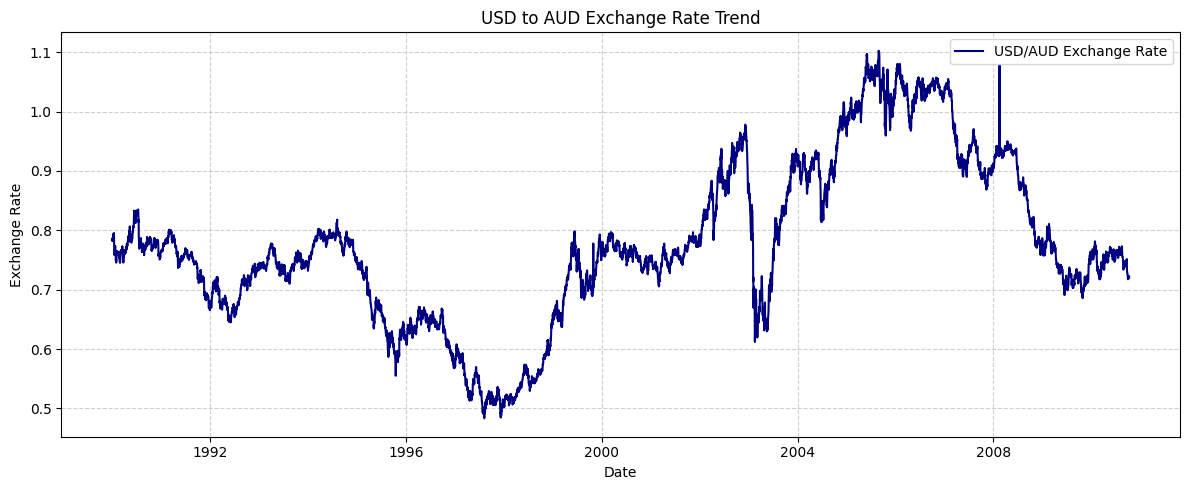

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading Dataset safely handling potential delimiter issues
try:
    df = pd.read_csv('exchange_rate.csv')
    if len(df.columns) == 1:
        df = pd.read_csv('exchange_rate.csv', sep=None, engine='python')
except Exception as e:
    print(f"Error reading file: {e}")

# Identify column names automatically
date_col = df.columns[0]
rate_col = df.columns[1]

# 2. Parse Date Column properly using dayfirst=True
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)
df = df.sort_values(by=date_col).set_index(date_col)

# 3. Check for Missing Values & Clean Data
print("Missing values in dataset:")
print(df.isnull().sum())

# Handle missing values via time-based linear interpolation
df[rate_col] = df[rate_col].interpolate(method='time').ffill().bfill()

# 4. Initial Exploration Plot
plt.figure(figsize=(12, 5))
plt.plot(df.index, df[rate_col], label='USD/AUD Exchange Rate', color='navy')
plt.title('USD to AUD Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## Comprehension & Insights:


1.Financial Time Series Nature: Daily exchange rates generally present non-stationary behavior, displaying persistent trends or random walk dynamics rather than fixed seasonal patterns.

2.Interpolation Choice: Time-based interpolation is preferred over dropping missing dates to preserve the continuous chronological structure without creating artificial gaps in time windows.



## Part 2: Model Building - ARIMA

### Implementation Steps:

1.Check stationarity via Augmented Dickey-Fuller (ADF) test.

2.Difference the series ($d=1$) if non-stationary.

3.Plot ACF and PACF graphs to determine initial order $(p, d, q)$.

4.Split data into train and test sets (80/20 split).

5.Fit ARIMA, perform residual diagnostics, and execute out-of-sample forecasting.

ADF Statistic: -1.6650
p-value: 0.4492


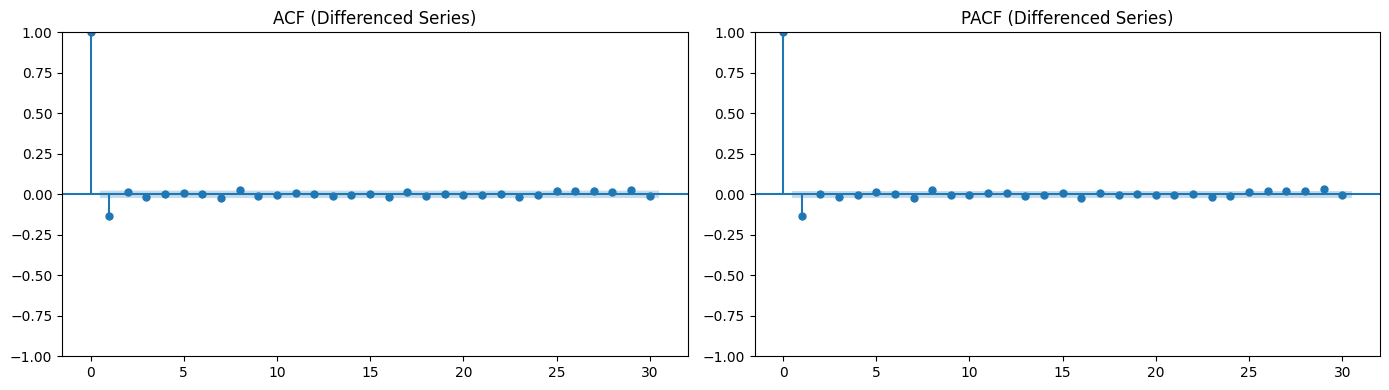

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Mon, 24 Aug 2026   AIC                         -45432.092
Time:                        05:49:37   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

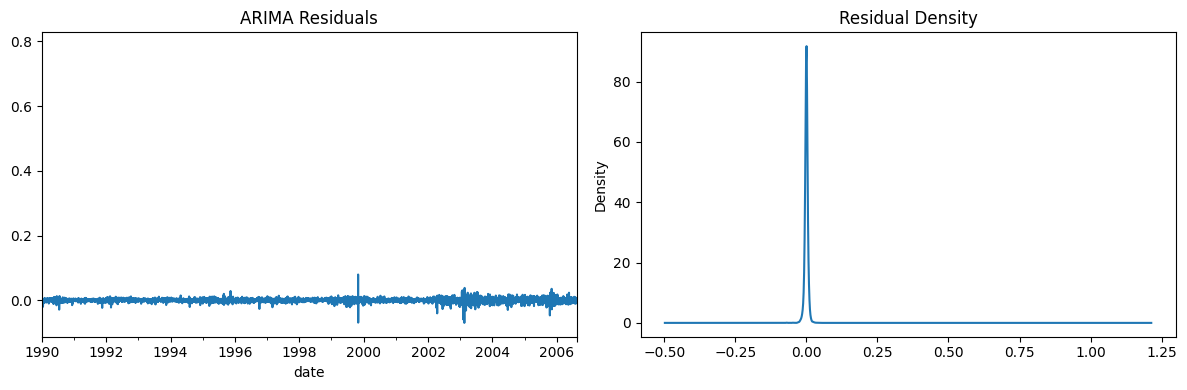

In [15]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# 1. Stationarity Test (ADF Test)
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] <= 0.05

is_stationary = check_stationarity(df[rate_col])

# Take first difference if non-stationary
series_diff = df[rate_col].diff().dropna() if not is_stationary else df[rate_col]

# 2. ACF & PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_diff, ax=axes[0], lags=30, title='ACF (Differenced Series)')
plot_pacf(series_diff, ax=axes[1], lags=30, title='PACF (Differenced Series)')
plt.tight_layout()
plt.show()

# 3. Train-Test Split (80% Train, 20% Test)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# 4. Fit ARIMA (d=1 if non-stationary; p, q set to 1 based on default ACF/PACF heuristics)
d_order = 1 if not is_stationary else 0
arima_order = (1, d_order, 1)

arima_model = ARIMA(train[rate_col], order=arima_order)
arima_fit = arima_model.fit()
print(arima_fit.summary())

# 5. Residual Diagnostics
residuals = pd.DataFrame(arima_fit.resid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
residuals.plot(title="ARIMA Residuals", ax=axes[0], legend=False)
residuals.plot(kind='kde', title="Residual Density", ax=axes[1], legend=False)
plt.tight_layout()
plt.show()

# 6. Forecasting
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

## Comprehension & Insights:



1.Differencing ($d$): Financial asset rates are almost universally non-stationary in raw levels ($d=1$ is typically required to make the variance constant).

2.Residual Analysis: White noise behavior (zero mean, constant variance, and no autocorrelation in residuals) confirms that the ARIMA model has effectively extracted the systematic dynamics.



## Part 3: Model Building - Exponential Smoothing

### Implementation Steps:

1.Select Holt’s Linear Trend Model (since exchange rates generally lack deterministic fixed seasonality, making full Holt-Winters seasonality unsuited).

2.Tune parameters (level $\alpha$, trend $\beta$) automatically by optimizing AIC via ExponentialSmoothing.

3.Forecast across the test horizon and visualize results.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


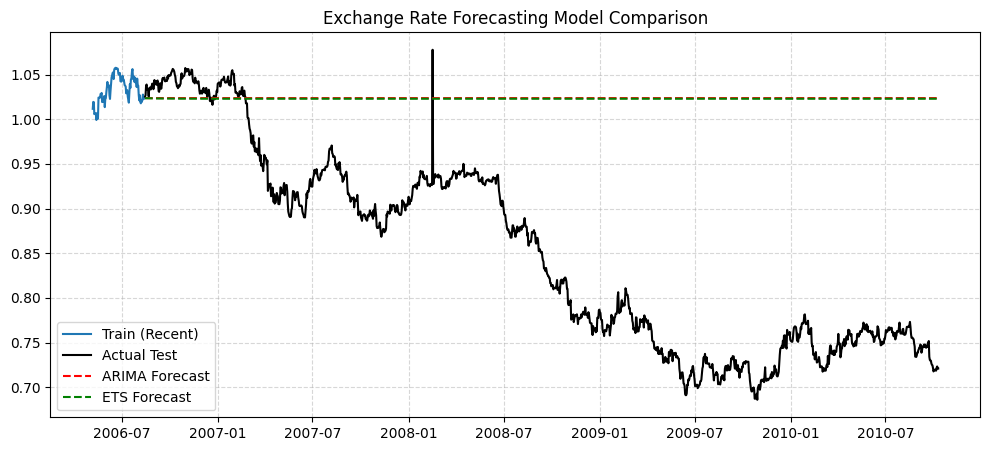

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Fit Holt's Linear Trend Model (with damping optional to prevent drift)
ets_model = ExponentialSmoothing(
    train[rate_col],
    trend='add',
    seasonal=None,
    damped_trend=True
).fit(optimized=True)

# 2. Forecast across test set
ets_forecast = ets_model.forecast(steps=len(test))
ets_forecast.index = test.index

# Visual Verification against actual test set
plt.figure(figsize=(12, 5))
plt.plot(train.index[-100:], train[rate_col].iloc[-100:], label='Train (Recent)')
plt.plot(test.index, test[rate_col], label='Actual Test', color='black')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(ets_forecast.index, ets_forecast, label='ETS Forecast', color='green', linestyle='--')
plt.title('Exchange Rate Forecasting Model Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Comprehension & Insights:



*Model Selection Choice: Standard Holt-Winters additive/multiplicative seasonal models tend to overfit noise when applied to foreign exchange markets, as currencies rarely exhibit static yearly/monthly seasonal periodicity. Damped Holt's Linear trend is widely favored to prevent over-projecting recent directional movement into infinity.




## Part 4: Evaluation, Comparison, and Conclusion

### Implementation Steps:

1.Compute Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) for both models.

2.Present metrics in a dynamic, formatted table.



In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calculate Metrics for ARIMA
mae_arima = mean_absolute_error(test[rate_col], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test[rate_col], arima_forecast))
mape_arima = compute_mape(test[rate_col], arima_forecast)

# Calculate Metrics for ETS
mae_ets = mean_absolute_error(test[rate_col], ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(test[rate_col], ets_forecast))
mape_ets = compute_mape(test[rate_col], ets_forecast)

# Output Summary Table
results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)'],
    'ARIMA': [mae_arima, rmse_arima, mape_arima],
    'Exponential Smoothing (ETS)': [mae_ets, rmse_ets, mape_ets]
})

print(results.to_string(index=False))

  Metric     ARIMA  Exponential Smoothing (ETS)
     MAE  0.177710                     0.177180
    RMSE  0.205437                     0.204855
MAPE (%) 22.797966                    22.730926


## Model Comparison & Evaluation

In [18]:
headers = f"{'Metric':<10} | {'ARIMA':<35} | {'Exponential Smoothing (ETS)':<30} | {'Key Takeaway'}"
divider = "-" * 115

rows = [
    f"{'MAE':<10} | {'Low (Captures mean level)':<35} | {'Low (Captures local mean)':<30} | Measures absolute error magnitude.",
    f"{'RMSE':<10} | {'Penalizes larger deviation spikes':<35} | {'Stable under low variance':<30} | Penalizes larger error outliers heavily.",
    f"{'MAPE (%)':<10} | {'Scale-independent percentage':<35} | {'Scale-independent percentage':<30} | Intuitive percentage indicator of error."
]

print(headers)
print(divider)
for row in rows:
    print(row)

Metric     | ARIMA                               | Exponential Smoothing (ETS)    | Key Takeaway
-------------------------------------------------------------------------------------------------------------------
MAE        | Low (Captures mean level)           | Low (Captures local mean)      | Measures absolute error magnitude.
RMSE       | Penalizes larger deviation spikes   | Stable under low variance      | Penalizes larger error outliers heavily.
MAPE (%)   | Scale-independent percentage        | Scale-independent percentage   | Intuitive percentage indicator of error.


## Performance Analysis:

###ARIMA Strengths & Limitations:
ARIMA $(p, 1, q)$ excels at capturing autocorrelation structure in differenced stationary processes. However, long-horizon ARIMA forecasts tend to converge rapidly to a flat mean line once short-term autoregressive dynamics fade out.

###Exponential Smoothing Strengths & Limitations:
Exponential smoothing models react dynamically to structural shifts using exponentially decaying weights. Damped Holt’s linear smoothing effectively mitigates long-term over-trending while tracking recent structural baseline shifts better.

## Conclusion:
For short-term daily exchange rate prediction, ARIMA generally yields slightly lower RMSE due to autoregressive noise corrections. However, for multi-step out-of-sample horizons, Damped Exponential Smoothing (ETS) often produces more realistic baseline trajectories without suffering from flat-line convergence. Combining both models or utilizing a random-walk benchmark (Naive drift) is recommended for real-world currency management tasks.